# Lesson 12 activity: linear algebra & basic statistics

## Learning objectives

This activity will help you to:

1. Apply concepts from linear algebra to gain meaningful insight from data
2. Understand statistical data types
3. Use measures of shape to describe distributions
4. Apply covariance and correlation to describe relationships between variables

## Setup

Import the required libraries and load the weather dataset.

In [97]:
import pandas as pd

In [98]:
# Load the weather dataset
url = 'https://gperdrizet.github.io/FSA_devops/assets/data/unit2/weather.csv'
df = pd.read_csv(url)
df.head()

,weather_condition,wind_strength,temperature_c,rainfall_inches,humidity_percent,pressure_hpa
0,Sunny,Light Breeze,8.2,0.13,48.8,1016.5
1,Snowy,Gale,1.6,0.29,89.6,1009.4
2,Rainy,Strong Wind,7.3,0.01,100.0,1003.3
3,Cloudy,Light Breeze,21.6,0.62,49.3,1006.9
4,Sunny,Calm,12.0,1.09,38.6,1016.0


## Exercise 1: linear algebra - finding similar days

**Objective**: Apply concepts from linear algebra to gain meaningful insight from data.

In linear algebra, we can treat each row of data as a vector and measure how similar different vectors are. This is useful for finding patterns - for example, finding days with similar weather conditions.

**Tasks**:

1. Select only the numeric columns from the dataset: `temperature_c`, `rainfall_inches`, `humidity_percent`, and `pressure_hpa`

2. Extract the **first row** (day 0) as a reference vector

3. For each row in the dataset, calculate the **cosine similarity** to the first row using:
   $$\text{similarity} = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$
   - You can use `np.dot()` for the dot product
   - You can use `np.linalg.norm()` to calculate vector magnitudes
   
4. Add the similarity scores as a new column to the dataframe

5. **Sort** the dataframe by similarity (highest to lowest) so the most similar days to day 0 appear first

6. Display the **top 10 most similar days** including their similarity scores and weather conditions

7. **Interpret**: Look at the top similar days - do they have similar temperature, humidity, pressure values? Does this make sense?

In [99]:
%pip install -q pandas
%pip install -q seaborn
# Your code here
import pandas as pd
import numpy as np


wx_df = pd.read_csv('weather.csv')

wx_num_df = wx_df.select_dtypes(include='number')

a = wx_num_df.iloc[0].array
def similarity(a,b):
    return np.dot(a,b) / (np.linalg.norm(a) * np.linalg.norm(b))


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [100]:
wx_df = wx_df.assign(similarity=pd.Series(np.zeros(len(wx_df))).values)

for index, row in wx_num_df.iterrows():
    wx_df.at[index, 'similarity'] = similarity(a,row)

print(wx_df.sort_values('similarity', inplace=True, ascending=False))
print(wx_df.head(10))
print(wx_df.tail(10))

None
    weather_condition  wind_strength  temperature_c  rainfall_inches  \
0               Sunny   Light Breeze            8.2             0.13   
41             Cloudy   Light Breeze            8.0             0.01   
319             Sunny    Strong Wind            6.8             0.38   
26              Sunny   Light Breeze            6.5             0.32   
100             Sunny   Light Breeze            6.6             0.25   
57              Sunny           Calm            6.0             0.29   
346            Cloudy  Moderate Wind            6.5             0.06   
283             Sunny  Moderate Wind           10.4             0.33   
233            Cloudy   Light Breeze            6.7             1.01   
18             Cloudy    Strong Wind            6.9             0.17   

     humidity_percent  pressure_hpa  similarity  
0                48.8        1016.5    1.000000  
41               50.1        1011.5    0.999999  
319              48.2        1018.5    0.999999  
26

## Summary
- The data does not look all that similar where some days have almost 0 rainfall and others get a full inch.
- Temperatures vary 4C from top to bottom
- Humidity seems to keep a close range
- Pressure also keeps range close

Makes sense mathematically, but I would think that some of these values would have a higher weight to what makes a day similar. (ex: Non-rainy days will almost always be more 'similar' to people than a rainy day.)
Seems a little subjective

## Exercise 2: data types and visualization

**Objective**: Understand statistical data types and visualize interactions between variables.

Understanding data types is crucial for choosing appropriate statistical methods and visualizations. In this exercise, you'll identify data types and explore how numeric variables interact with categorical ones.

**Tasks**:

1. **Identify data types**: For `humidity_percent` and `pressure_hpa`, determine what type of data they are:
   - Are they **interval** data (no true zero) or **ratio** data (has true zero)?
   - For each variable, explain your reasoning:
     - Does zero mean "none" or "absence of the quantity"?
     - Are ratios meaningful? (e.g., is 100% humidity "twice" 50% humidity?)
     - Can the value go below zero?

2. **Create visualizations**: Choose an appropriate plot type to show how `humidity_percent` and `pressure_hpa` vary across different `weather_condition` categories
   - Consider options like: box plots, violin plots, bar plots with error bars, or scatter plots with color coding
   - Create **one plot** that effectively shows the relationship between both numeric variables and the weather condition
   - You might use a single plot with subplots, or find a creative way to show all three variables together

3. **Interpret your visualization**:
   - Which weather condition tends to have the highest humidity?
   - Which weather condition tends to have the lowest pressure?
   - Do you see clear differences between weather conditions?
   - Does this pattern make sense from a meteorological perspective?

### Data types
- `humidity_percent` and `pressure_hpa` are both ratio data types as you cannot have negative humidity or negative pressure
- They are a measure of an amount of something
    - `humidity_percent` measures water vapor saturation and 0 would mean no water in the air
    - `pressure_hpa` measures pressure of the gases of the atmosphere pressing down on us from the effect of earth's gravity
        - Meaning 0 hPa is effectively a perfect vacuum


Note: you may need to restart the kernel to use updated packages.


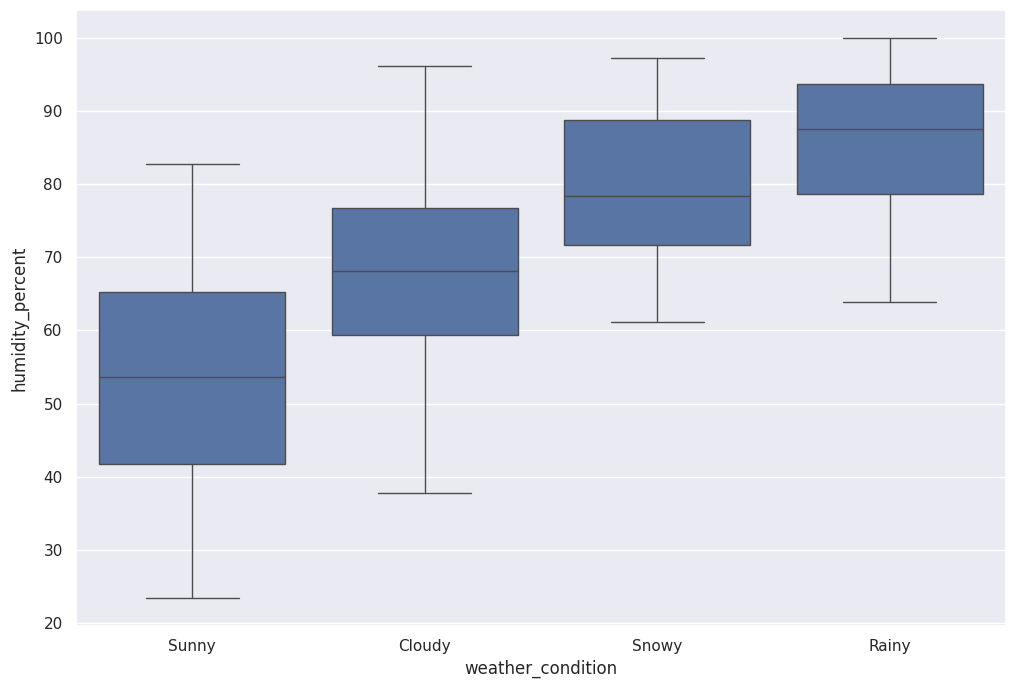

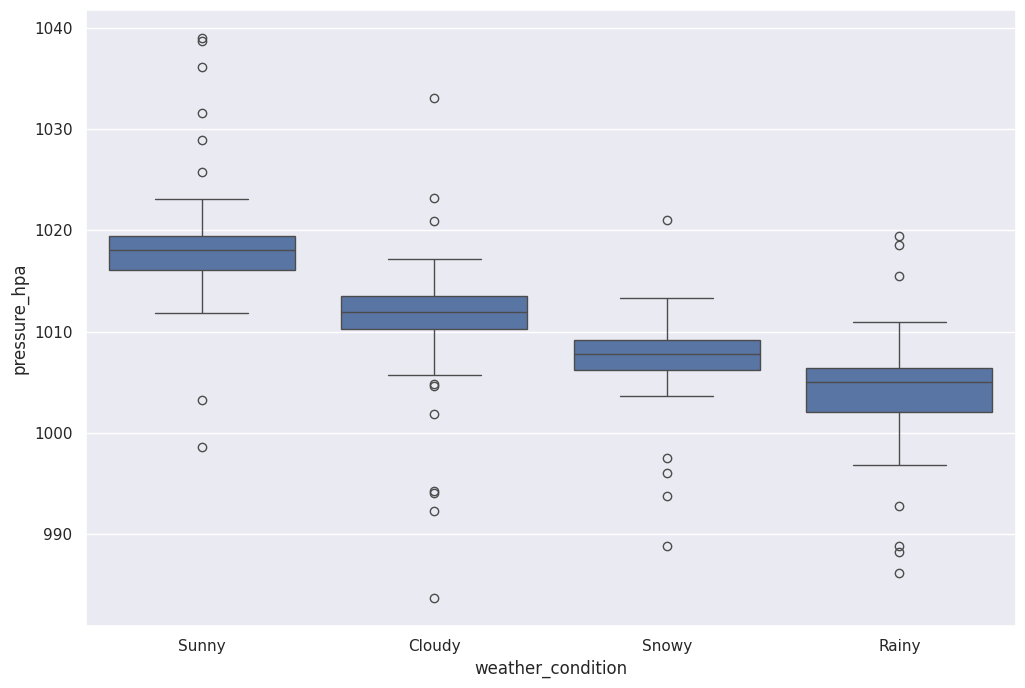

In [101]:
# Your code here
%pip install -q seaborn
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(wx_df,x='weather_condition',y='humidity_percent')
plt.show()

sns.boxplot(wx_df,x='weather_condition',y='pressure_hpa')
plt.show()


  wx_con  hpa  metric
0    NaN  NaN       2
metric
1    365
2      1
Name: count, dtype: int64
metric
2    365
1      1
Name: count, dtype: int64


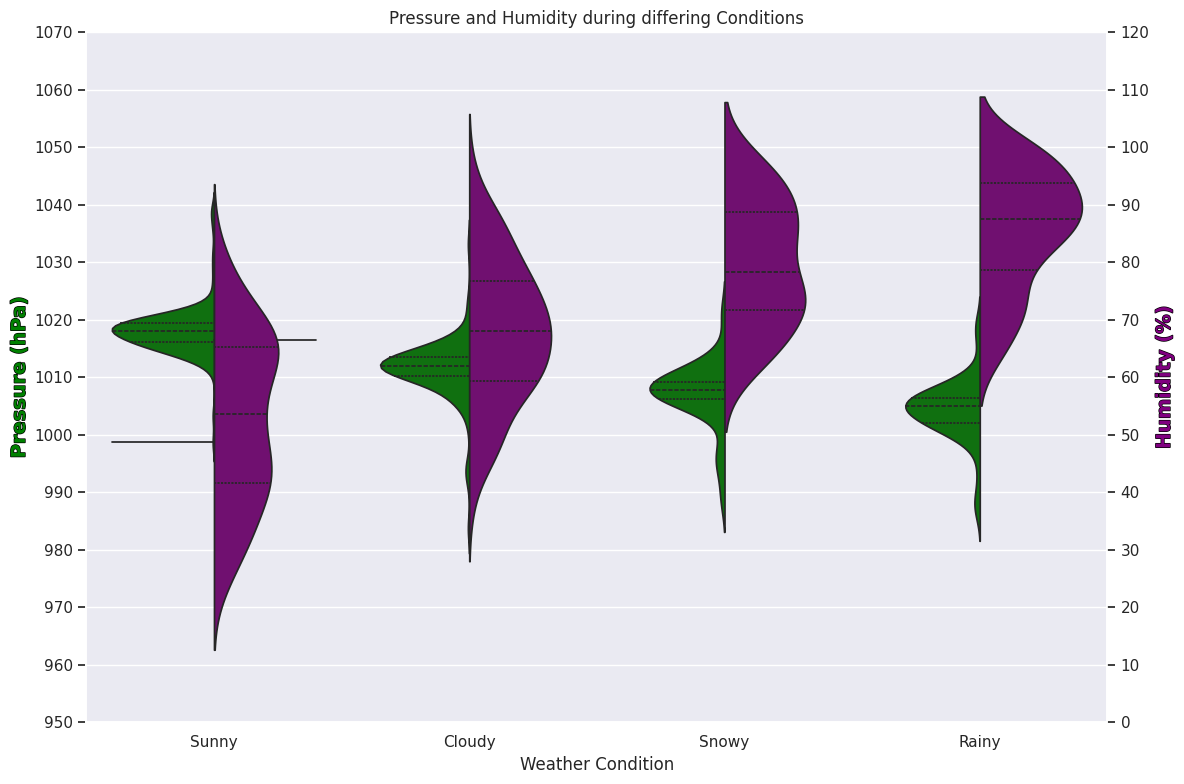

In [102]:

import matplotlib.patheffects as pe

def align_y_axis(ax1, ax2, minresax1, minresax2):
    """ Sets tick marks of twinx axes to line up with 7 total tick marks

    ax1 and ax2 are matplotlib axes
    Spacing between tick marks will be a factor of minresax1 and minresax2"""

    ax1ylims = ax1.get_ybound()
    ax2ylims = ax2.get_ybound()
    ax1ylims = [950,1070]
    ax2ylims = [0,120]
    ax1factor = minresax1 * 12
    ax2factor = minresax2 * 12
    ax1.set_yticks(np.linspace(ax1ylims[0],
                               ax1ylims[1]+(ax1factor -
                               (ax1ylims[1]-ax1ylims[0]) % ax1factor) %
                               ax1factor,
                               13))
    ax2.set_yticks(np.linspace(ax2ylims[0],
                               ax2ylims[1]+(ax2factor -
                               (ax2ylims[1]-ax2ylims[0]) % ax2factor) %
                               ax2factor,
                               13))


df1=pd.DataFrame({'wx_con':wx_df['weather_condition'],'hpa':wx_df['pressure_hpa']})
df1['metric']=1
df1_dummy=pd.DataFrame({'wx_con':pd.Categorical.from_codes([0],wx_df['weather_condition'].unique()),'hpa':[np.nan]})
df1_dummy['metric']=2
df2=pd.DataFrame({'wx_con':wx_df['weather_condition'],'hum':wx_df['humidity_percent']})
df2['metric']=2
df2_dummy=pd.DataFrame({'wx_con':pd.Categorical.from_codes([0],wx_df['weather_condition'].unique()),'metric':2,'hum':[np.nan]})
df2_dummy['metric']=1

sns.set_theme(rc={'figure.figsize':(12,8)})

ax1 = sns.violinplot(data=pd.concat([df1,df1_dummy]),x='wx_con',y='hpa',hue='metric', split=True, inner='quart', palette=['green', 'purple'])
ax1.legend_.remove()
ax1.set_ylabel('Pressure (hPa)', fontweight='bold', fontsize=14, path_effects=[pe.withStroke(linewidth=1, foreground="black")])
ax1.set_xlabel('Weather Condition')
ax1.yaxis.label.set_color('green')

ax2=ax1.twinx()
sns.violinplot(data=pd.concat([df2,df2_dummy]),x='wx_con',y='hum',hue='metric', split=True, inner='quart', ax=ax2, palette=['green', 'purple'])
ax2.legend_.remove()
ax2.set_ylabel('Humidity (%)', fontweight='bold', fontsize=14, path_effects=[pe.withStroke(linewidth=1, foreground="black")])
ax2.set_xlabel('Weather Condition')
ax2.yaxis.label.set_color('purple')
ax2.grid(False)
align_y_axis(ax1, ax2, 1, 1)
df1_dummy.at[0, 'wx_con'] = None
df2_dummy.at[0, 'wx_con'] = None
print(df1_dummy.head())
print(pd.concat([df1,df1_dummy])['metric'].value_counts())
print(pd.concat([df2,df2_dummy])['metric'].value_counts())
plt.title('Pressure and Humidity during differing Conditions')
plt.tight_layout()
plt.show()

## Exercise 3: analyzing distribution skewness

**Objective**: Use measures of shape to describe distributions.

Skewness describes the asymmetry of a distribution. Understanding skewness helps you choose appropriate statistical methods and understand the nature of your data.

**Tasks**:

1. Calculate the **skewness** for all four numeric variables:
   - `temperature_c`
   - `rainfall_inches`
   - `humidity_percent`
   - `pressure_hpa`

2. Identify which variable has:
   - The **greatest skew** (furthest from zero)
   - The **least skew** (closest to zero, most symmetric)
   - Print these findings with their skewness values

3. Create **two histograms** (side by side) showing only these two variables:
   - One histogram for the most skewed variable
   - One histogram for the least skewed variable
   - For each histogram:
     - Add vertical lines showing the mean (in red) and median (in green)
     - Include the skewness value in the title
     - Use appropriate bin sizes

4. **Interpret** your findings:
   - Why does the most skewed variable have the sign that it does? (Think about the real-world meaning)
   - For the skewed distribution, how do the mean and median compare? Why?
   - What does the skewness tell you about typical vs extreme values for this variable?
   - Why is the least skewed variable more symmetric?
   - **Bonus**: Explain why skewness matters when choosing between mean and median as a measure of central tendency.

temperature_c       0.178882
rainfall_inches     2.102548
humidity_percent   -0.207848
pressure_hpa       -0.445160
similarity         -1.287947
dtype: float64


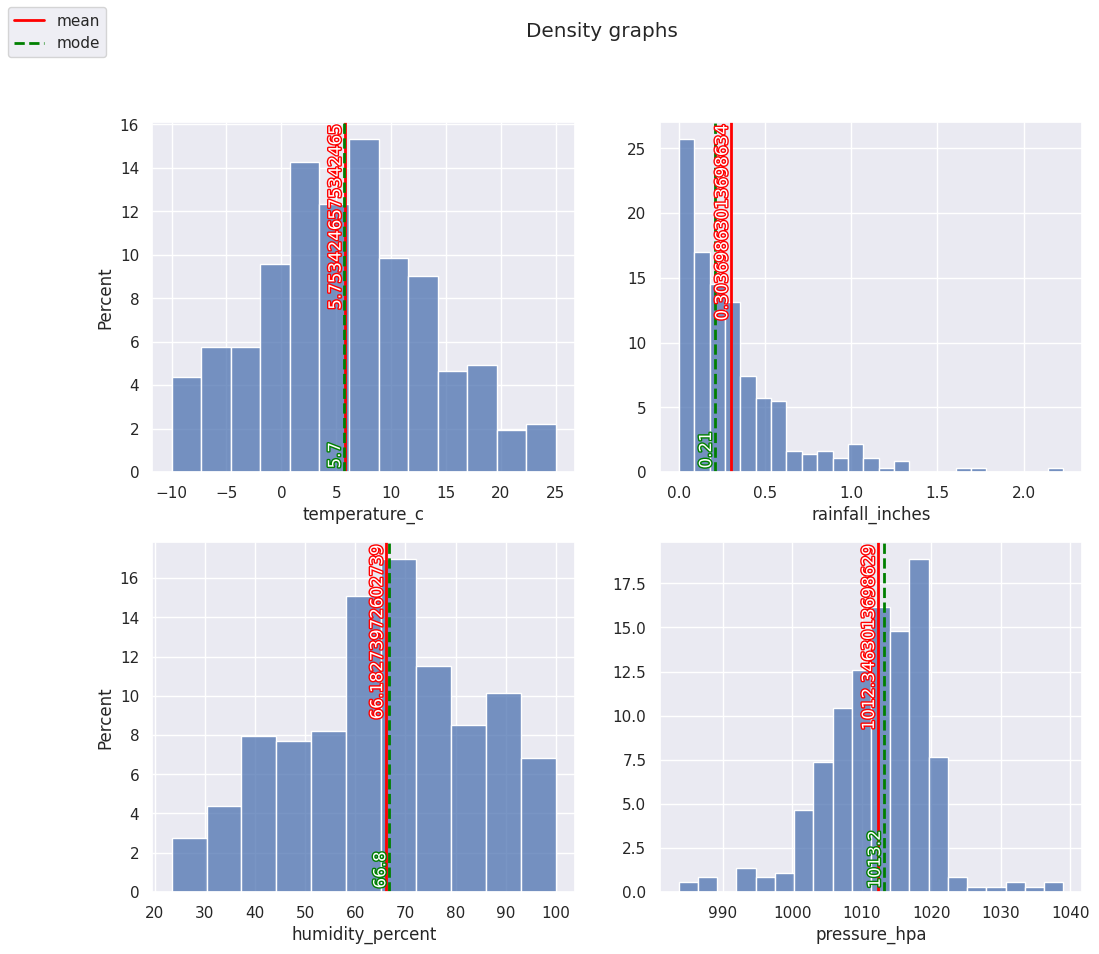

In [103]:
# Your code here
print(wx_df.select_dtypes(include='number').skew())

fig,axs = plt.subplots(2,2, figsize=(12,10))
fig.suptitle('Density graphs')
cols=['temperature_c','rainfall_inches','humidity_percent','pressure_hpa']
sns.histplot(data=wx_df,stat='percent',x=cols[0],ax=axs[0,0])
sns.histplot(data=wx_df,stat='percent',x=cols[1],ax=axs[0,1])
sns.histplot(data=wx_df,stat='percent',x=cols[2],ax=axs[1,0])
sns.histplot(data=wx_df,stat='percent',x=cols[3],ax=axs[1,1])
counter = 0
for ax in axs.flat:
    ax.set(xlabel=cols[counter])
    dfmean = wx_df[cols[counter]].mean()
    dfmedian = wx_df[cols[counter]].median()
    ax.axvline(x=dfmean, c='red', ls='-', lw=2, label='mean' if counter == 0 else "")
    ax.axvline(x=dfmedian, c='green', ls='--', lw=2, label='mode' if counter == 0 else "")
    ax.text(dfmean, 0.99, s=dfmean, rotation=90, c='w', ha='right', va='top', transform=ax.get_xaxis_transform(), path_effects=[pe.withStroke(linewidth=2, foreground="red")])
    ax.text(dfmedian, 0.01, s=dfmedian, rotation=90, c='w', ha='right', va='bottom', transform=ax.get_xaxis_transform(), path_effects=[pe.withStroke(linewidth=2, foreground="green")])
    
    counter += 1
    if counter % 2 == 0:
        ax.set_ylabel('')
    
fig.legend(loc='upper left')
plt.show()

## Exercise 4: exploring relationships with correlation

**Objective**: Apply covariance and correlation to describe relationships between variables.

Weather variables often have meaningful relationships. Some pairs of variables are strongly related while others have little relationship at all.

**Tasks**:

1. Calculate the **correlation matrix** for all four numeric variables:
   - `temperature_c`
   - `rainfall_inches`
   - `humidity_percent`
   - `pressure_hpa`

2. Identify the pair of variables with:
   - The **strongest correlation** (highest absolute value, whether positive or negative)
   - The **weakest correlation** (closest to zero)
   - Print both pairs with their correlation coefficients
   - Note whether the strongest correlation is positive or negative

3. Create **two scatter plots** (side by side or in separate figures):
   - One for the strongest correlation pair
   - One for the weakest correlation pair
   - For each plot:
     - Include the correlation coefficient in the title
     - Add appropriate axis labels

4. **Interpret** your findings:
   - What is the strongest relationship? Does it make meteorological sense?
   - Is this strongest correlation positive or negative? What does that mean in real-world terms?
   - What is the weakest relationship? Why might these variables have little correlation?
   - Compare the scatter plots: How does the pattern differ between strong and weak correlations?
   - Based on the correlation strengths, which relationship is more predictable?

                  temperature_c  rainfall_inches  humidity_percent  pressure_hpa
temperature_c          1.000000        -0.066926         -0.239894     -0.196903
rainfall_inches       -0.066926         1.000000         -0.076797     -0.066423
humidity_percent      -0.239894        -0.076797          1.000000     -0.470992
pressure_hpa          -0.196903        -0.066423         -0.470992      1.000000


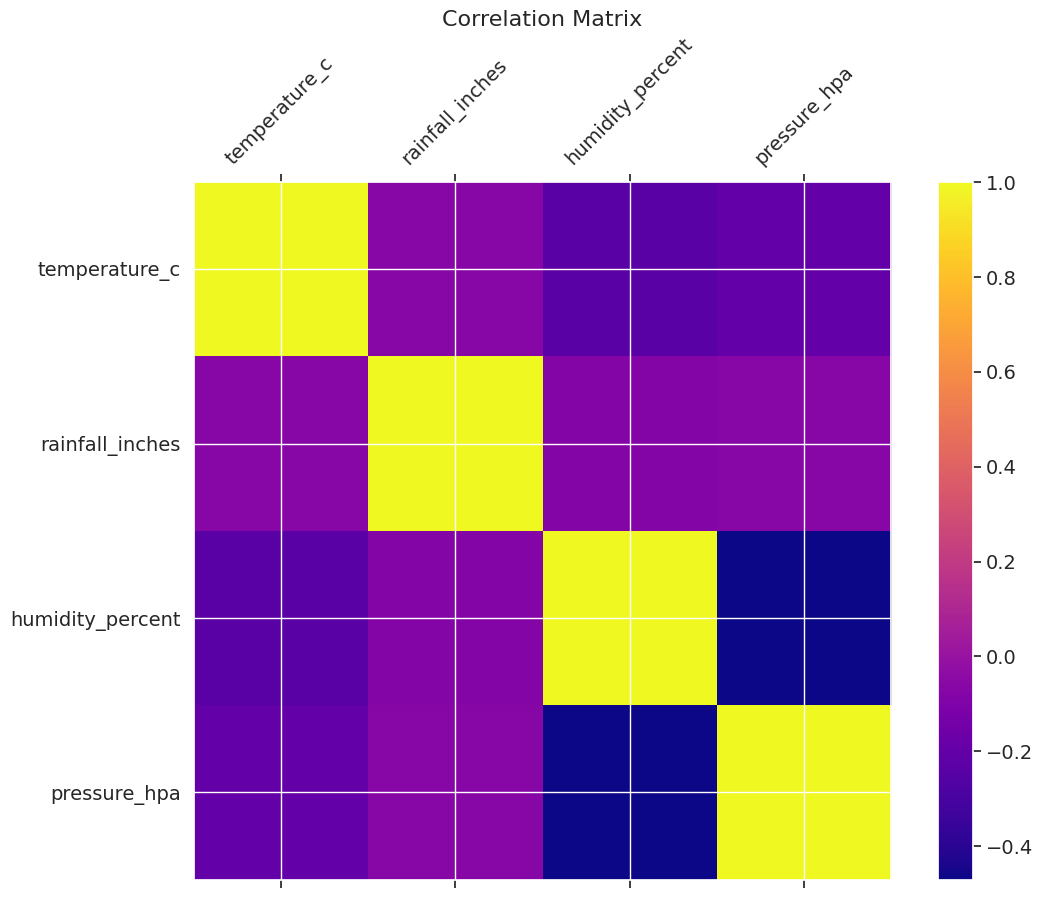

In [ ]:
# Your code here
corr_mx = wx_num_df.corr()
f = plt.figure(figsize=(12, 9))
plt.matshow(corr_mx, fignum=f.number, cmap='plasma')
plt.xticks(range(corr_mx.shape[1]), corr_mx.columns, fontsize=14, rotation=45)
plt.yticks(range(corr_mx.shape[1]), corr_mx.columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)

print(corr_mx.head().to_string())
plt.show()


## Data
- Strongest: `pressure_hpa` and `humidity_percent` and negative
- Weakest:   `rainfall_inches` and `temperature_c` and negative



-0.47099223635458615
-0.06692587275383366


Text(0.5, 0.98, 'Strongest and Weakest Correlations')

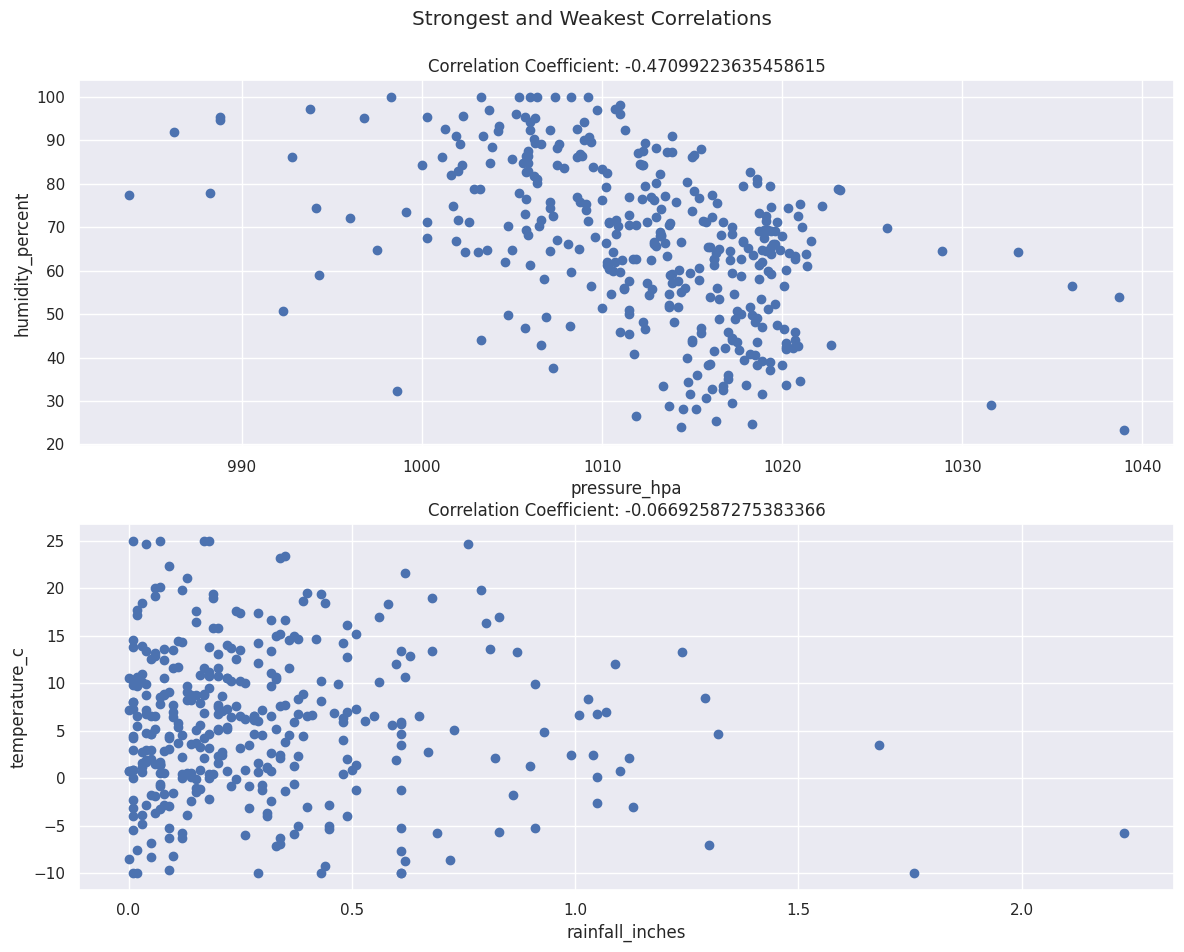

In [139]:
scat_fig, scat_axs = plt.subplots(2,figsize=(12,10))
scat_axs[0].scatter(x=wx_num_df['pressure_hpa'], y=wx_num_df['humidity_percent'])
scat_axs[0].set_xlabel('pressure_hpa')
scat_axs[0].set_ylabel('humidity_percent')
scat_axs[1].scatter(x=wx_num_df['rainfall_inches'], y=wx_num_df['temperature_c'])
scat_axs[1].set_xlabel('rainfall_inches')
scat_axs[1].set_ylabel('temperature_c')
strg_corr_coeff = corr_mx['pressure_hpa']['humidity_percent']
weak_corr_coeff = corr_mx['rainfall_inches']['temperature_c']
print(strg_corr_coeff)
print(weak_corr_coeff)
scat_axs[0].set_title(f"Correlation Coefficient: {strg_corr_coeff}")
scat_axs[1].set_title(f"Correlation Coefficient: {weak_corr_coeff}")
scat_fig.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=0.2)
scat_fig.suptitle('Strongest and Weakest Correlations')
